In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
streeteasy = pd.read_csv("streeteasy.csv")
df = pd.DataFrame(streeteasy)
print(df.head())

   rental_id  building_id   rent  bedrooms  bathrooms  size_sqft  \
0       1545     44518357   2550       0.0          1        480   
1       2472     94441623  11500       2.0          2       2000   
2      10234     87632265   3000       3.0          1       1000   
3       2919     76909719   4500       1.0          1        916   
4       2790     92953520   4795       1.0          1        975   

   min_to_subway  floor  building_age_yrs  no_fee  has_roofdeck  \
0              9    2.0                17       1             1   
1              4    1.0                96       0             0   
2              4    1.0               106       0             0   
3              2   51.0                29       0             1   
4              3    8.0                31       0             0   

   has_washer_dryer  has_doorman  has_elevator  has_dishwasher  has_patio  \
0                 0            0             1               1          0   
1                 0            0  

In [3]:
# Features and target
X = df[['bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor',
        'building_age_yrs', 'no_fee', 'has_roofdeck', 'has_washer_dryer',
        'has_doorman', 'has_elevator', 'has_dishwasher', 'has_patio', 'has_gym']]
y = df[['rent']]

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=6
)

In [4]:
# Fit model
mlr = LinearRegression()
mlr.fit(x_train, y_train)

# Predictions
y_predict = mlr.predict(x_test)

In [5]:
# Evaluation
print("Train R²:", mlr.score(x_train, y_train))
print("Test R²:", mlr.score(x_test, y_test))
print("Mean Squared Error:", mean_squared_error(y_test, y_predict))

# Coefficients with feature names
print("\nFeature Coefficients:")
for feature, coef in zip(X.columns, mlr.coef_[0]):
    print(f"{feature}: {coef:.2f}")

Train R²: 0.7349688159822418
Test R²: 0.71585652172282
Mean Squared Error: 2242620.050781128

Feature Coefficients:
bedrooms: -461.18
bathrooms: 1278.60
size_sqft: 4.82
min_to_subway: -14.95
floor: 38.71
building_age_yrs: -4.52
no_fee: -90.27
has_roofdeck: 90.65
has_washer_dryer: 196.97
has_doorman: -41.55
has_elevator: 224.21
has_dishwasher: 9.03
has_patio: 24.12
has_gym: -86.38


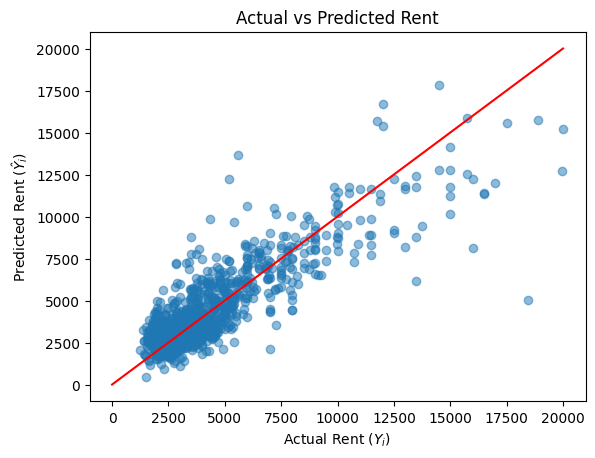

In [6]:
# Scatter: actual vs predicted
plt.scatter(y_test, y_predict, alpha=0.5)
plt.plot(range(20000), range(20000), color="red")
plt.xlabel("Actual Rent ($Y_i$)")
plt.ylabel("Predicted Rent ($Ŷ_i$)")
plt.title("Actual vs Predicted Rent")
plt.show()

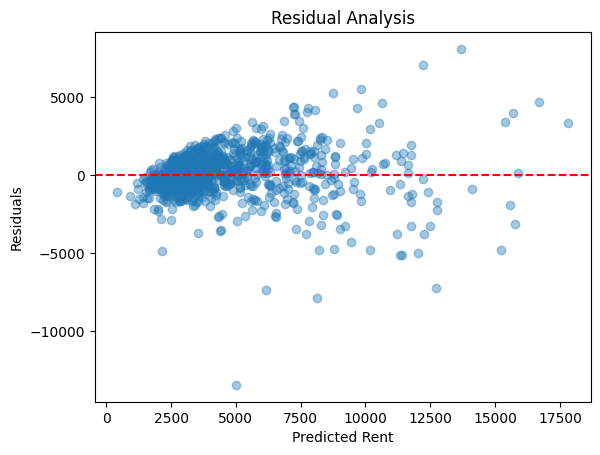

In [7]:
residuals = y_predict - y_test
plt.scatter(y_predict, residuals, alpha=0.4)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Analysis")
plt.xlabel("Predicted Rent")
plt.ylabel("Residuals")
plt.show()

In [8]:
sonny_apartment = [[1, 1, 620, 16, 1, 98, 1, 0, 1, 0, 0, 1, 1, 0]]
predicted_rent = mlr.predict(sonny_apartment)
print("\nPredicted rent for Sonny's apartment: $%.2f" % predicted_rent)


Predicted rent for Sonny's apartment: $2258.75


C:\Users\apexf\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\apexf\AppData\Local\Temp\ipykernel_18940\3189240188.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("\nPredicted rent for Sonny's apartment: $%.2f" % predicted_rent)
